# Airbnb Price Prediction Model

This notebook implements an end-to-end machine learning pipeline for predicting Airbnb listing prices with three tree-based models: **Random Forest**, **XGBoost**, and **LightGBM**.

---

## Pipeline Overview

### 1. Setup and Imports
- **Data manipulation:** `pandas`, `numpy`
- **Visualization:** `matplotlib`
- **ML models:** `RandomForestRegressor`, `XGBRegressor`, `LGBMRegressor`
- **Evaluation metrics:** `mean_squared_error`, `mean_absolute_error`, `r2_score`
- **Preprocessing:** `LabelEncoder`
- **Hyperparameter optimization:** `optuna`
- **Cross-validation:** `KFold`, `train_test_split`
- **Model export:** `joblib`

### 2. Data Loading and Initial Exploration
- Load the Airbnb dataset (261,894 rows × 55 columns)
- Inspect data types and missing values
- Review dataset shape and basic structure

### 3. Data Cleaning
- Drop columns with more than 50% missing values
- Drop text and identifier columns that are not used for modeling
- Fill missing numerical values with the median
- Fill missing categorical values with the mode
- Remove duplicate rows

### 4. Outlier Removal
- Remove invalid prices (`price <= 0`)
- Filter extreme price outliers using the 1st and 99th percentiles
- Compare price statistics before and after filtering

### 5. Exploratory Data Analysis
- Create price categories: **Budget**, **Mid-Range**, **Premium**, **Luxury**
- Visualize the original and log-transformed price distribution

### 6. Feature Engineering
- Add interaction and ratio features
- Add `amenities_count` from the raw amenities field
- Add location features such as `lat_long_interaction` and `distance_to_center`

### 7. Target Transformation
- Apply `np.log1p(price)` to reduce target skewness
- Convert predictions back with `np.expm1()` during evaluation

### 8. Categorical Encoding
- Ordinal encode `price_class`
- Label encode binary categorical columns
- One-hot encode low-cardinality categorical columns
- Target encode high-cardinality categorical columns after the split

### 9. Train-Test Split
- Split data into 80% training and 20% testing
- Keep features unscaled because tree-based models are threshold-based

### 10. Baseline Model Training
- Train default Random Forest, XGBoost, and LightGBM models
- Evaluate with RMSE, MAE, R², and RMSLE

### 11. Cross-Validation Evaluation
- Run 5-fold cross-validation with fold-safe target encoding
- Report mean CV RMSE in log space

### 12. Hyperparameter Tuning
- Use Optuna with fold-safe target encoding inside each validation fold
- Tune all three models and evaluate on the holdout test set

### 13. Model Comparison and Visualization
- Combine baseline and tuned results in one table
- Visualize RMSE, R², and MAE for tuned models
- Select the best model using the highest R² score

### 14. Model Export
- Map the selected model name to the trained model object
- Save the best model with `joblib.dump()`

### 15. Model Verification
- Predict 50 holdout samples
- Compare actual vs predicted prices in tabular and graphical form


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Imports

In [2]:
%pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.7 MB/s eta 0:00:00


In [3]:
import optuna
print(optuna.__version__)

4.8.0


In [4]:
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

print("All libraries imported")


All libraries imported


## 2. Data Loading & Initial Exploration

In [1]:
# OUTPUT_DIR = ('/content/drive/MyDrive/Colab Notebooks/Dataset AirBnB & Notebook/datasetairbnb.csv')
import pandas as pd
OUTPUT_DIR = ('datasetairbnb.csv')
df = pd.read_csv(OUTPUT_DIR)


In [6]:

print(f"Dataset loaded: {df.shape[0]} rows \u00d7 {df.shape[1]} columns")

print(f"\nData types:")
print(df.dtypes.value_counts())

print(f"\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Dataset loaded: 261894 rows × 55 columns

Data types:
object     25
float64    20
int64      10
Name: count, dtype: int64

Missing values (top 10):
host_neighbourhood           158979
estimated_occupancy_l365d    139665
estimated_revenue_l365d      139665
availability_eoy             139665
number_of_reviews_ly         139665
neighborhood_overview        134207
neighbourhood                134206
host_about                   126186
host_location                 66830
review_scores_checkin         50967
dtype: int64


## 3. Data Cleaning (Missing Values & Duplicates)

In [7]:
# Drop columns with >50% missing values
threshold = 0.5

missing_pct = df.isnull().sum() / len(df)
high_missing_cols = missing_pct[missing_pct > threshold].index.tolist()
print(f"Columns with >{threshold*100}% missing values (to be dropped):")
print(high_missing_cols)
df.drop(columns=high_missing_cols, inplace=True)

# Drop text/identifier columns that are not relevant for modeling
text_id_cols = ['id', 'name', 'description', 'host_id', 'host_name',
                'host_since', 'host_location', 'host_about',
                'host_verifications', 'bathrooms_text',
                'first_review', 'last_review']
existing_text_cols = [c for c in text_id_cols if c in df.columns]
df.drop(columns=existing_text_cols, inplace=True)
print(f"\nText/ID columns dropped: {existing_text_cols}")

# Fill missing values: numerical with median, categorical with mode
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols: # Mengisi nilai yang hilang dengan median
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols: # Mengisi nilai yang hilang dengan mode
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# Check and remove duplicates
n_dup = df.duplicated().sum()
print(f"\nNumber of duplicates: {n_dup}")
if n_dup > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. Shape: {df.shape}")

print(f"\nShape after cleaning: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Columns with >50.0% missing values (to be dropped):
['neighborhood_overview', 'host_neighbourhood', 'neighbourhood', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']

Text/ID columns dropped: ['id', 'name', 'description', 'host_id', 'host_name', 'host_since', 'host_location', 'host_about', 'host_verifications', 'bathrooms_text', 'first_review', 'last_review']

Number of duplicates: 156
Duplicates removed. Shape: (261738, 36)

Shape after cleaning: (261738, 36)
Remaining missing values: 0


## 4. Outlier Removal

In [8]:
# Price distribution before outlier removal
print(f"\nPrice statistics BEFORE outlier removal:")
print(df['price'].describe())

# Remove extreme outliers using percentile-based method
Q1 = df['price'].quantile(0.01)
Q3 = df['price'].quantile(0.99)
print(f"\nPercentile 1%: {Q1}, Percentile 99%: {Q3}")

# Remove zero/negative prices and extreme high prices
df = df[(df['price'] > 0) & (df['price'] >= Q1) & (df['price'] <= Q3)]

print(f"\nPrice statistics AFTER outlier removal:")
print(df['price'].describe())
print(f"Shape after outlier removal: {df.shape}")


Price statistics BEFORE outlier removal:
count    261738.000000
mean        207.070632
std         197.275840
min           0.000000
25%          81.000000
50%         136.000000
75%         250.000000
max        1000.000000
Name: price, dtype: float64

Percentile 1%: 29.0, Percentile 99%: 950.0

Price statistics AFTER outlier removal:
count    256678.000000
mean        201.005365
std         182.176230
min          29.000000
25%          82.000000
50%         136.000000
75%         245.000000
max         950.000000
Name: price, dtype: float64
Shape after outlier removal: (256678, 36)


## 5. Exploratory Data Analysis (EDA)


Price Class Distribution:
price_class
Mid-Range    104167
Budget        91664
Premium       40542
Luxury        20305
Name: count, dtype: int64


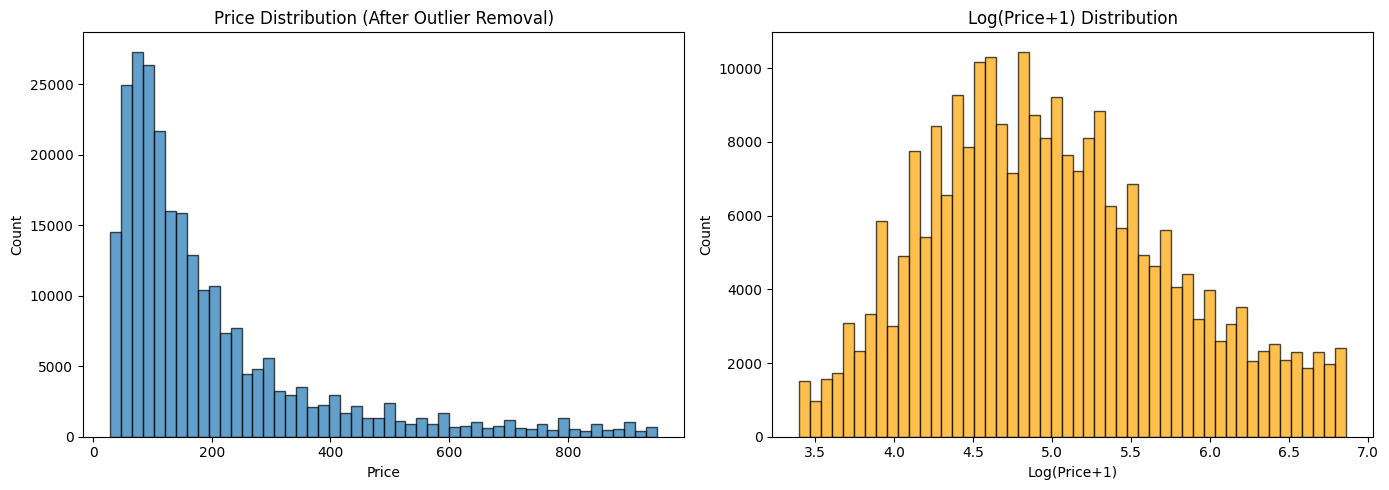

In [9]:
# Create price categories for analysis
def categorize_price(price):
    if price <= 100:
        return 'Budget'
    elif price <= 250:
        return 'Mid-Range'
    elif price <= 500:
        return 'Premium'
    else:
        return 'Luxury'

df['price_class'] = df['price'].apply(categorize_price)
print("\nPrice Class Distribution:")
print(df['price_class'].value_counts())

# Visualize price distribution after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution (After Outlier Removal)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Log(Price+1) Distribution')
axes[1].set_xlabel('Log(Price+1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [10]:
# Create interaction and ratio features to capture non-linear relationships

if 'bedrooms' in df.columns and 'bathrooms' in df.columns:
    df['room_bath_ratio'] = df['bedrooms'] / (df['bathrooms'] + 0.01)
    print("✓ Feature 'room_bath_ratio' added")

if 'bedrooms' in df.columns and 'beds' in df.columns:
    df['total_capacity'] = df['bedrooms'] * df['beds']
    print("✓ Feature 'total_capacity' added")

if 'accommodates' in df.columns and 'bedrooms' in df.columns:
    df['accommodates_x_bedrooms'] = df['accommodates'] * df['bedrooms']
    print("✓ Feature 'accommodates_x_bedrooms' added")

if 'accommodates' in df.columns and 'bathrooms' in df.columns:
    df['accommodates_x_bathrooms'] = df['accommodates'] * df['bathrooms']
    print("✓ Feature 'accommodates_x_bathrooms' added")

review_cols = [column for column in df.columns if column.startswith('review_scores_')]
if review_cols:
    df['review_scores_composite'] = df[review_cols].mean(axis=1)
    print(f"✓ Feature 'review_scores_composite' added (from {len(review_cols)} review columns)")

if 'availability_365' in df.columns:
    df['availability_ratio'] = df['availability_365'] / 365.0
    print("✓ Feature 'availability_ratio' added")

if 'amenities' in df.columns:
    df['amenities_count'] = df['amenities'].apply(
        lambda value: len(str(value).split(',')) if pd.notna(value) else 0
    )
    df.drop(columns=['amenities'], inplace=True, errors='ignore')
    print("✓ Feature 'amenities_count' added")

if 'latitude' in df.columns and 'longitude' in df.columns:
    df['lat_long_interaction'] = df['latitude'] * df['longitude']
    center_lat = df['latitude'].mean()
    center_lon = df['longitude'].mean()
    df['distance_to_center'] = (
        (df['latitude'] - center_lat) ** 2 + (df['longitude'] - center_lon) ** 2
    ) ** 0.5
    print("✓ Features 'lat_long_interaction' and 'distance_to_center' added")

print(f"\nShape after Feature Engineering: {df.shape}")

✓ Feature 'room_bath_ratio' added
✓ Feature 'total_capacity' added
✓ Feature 'accommodates_x_bedrooms' added
✓ Feature 'accommodates_x_bathrooms' added
✓ Feature 'review_scores_composite' added (from 7 review columns)
✓ Feature 'availability_ratio' added
✓ Feature 'amenities_count' added
✓ Features 'lat_long_interaction' and 'distance_to_center' added

Shape after Feature Engineering: (256678, 45)


## 7. Target Transformation (Log Transform)


Original price statistics:
count    256678.000000
mean        201.005365
std         182.176230
min          29.000000
25%          82.000000
50%         136.000000
75%         245.000000
max         950.000000
Name: price, dtype: float64

Log-transformed price statistics:
count    256678.000000
mean          4.995160
std           0.768861
min           3.401197
25%           4.418841
50%           4.919981
75%           5.505332
max           6.857514
Name: log_price, dtype: float64


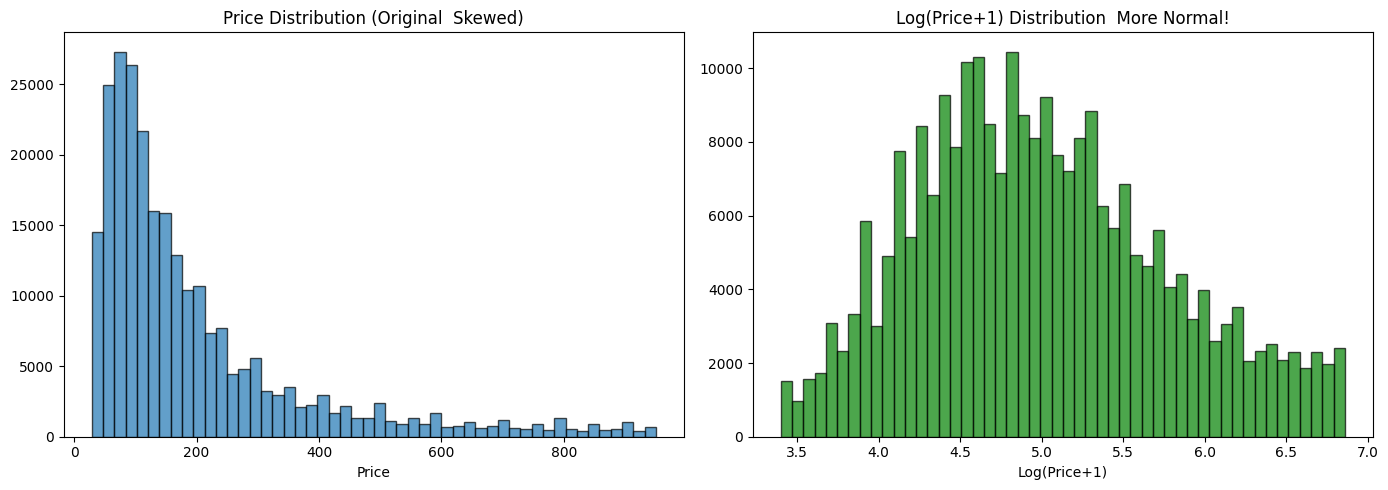

In [11]:
# Apply log transform to reduce skewness of the target variable
# np.log1p(x) = log(x + 1) avoids log(0)
df['log_price'] = np.log1p(df['price'])

print(f"\nOriginal price statistics:")
print(df['price'].describe())
print(f"\nLog-transformed price statistics:")
print(df['log_price'].describe())

# Visualize distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution (Original  Skewed)')
axes[0].set_xlabel('Price')

axes[1].hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Log(Price+1) Distribution  More Normal!')
axes[1].set_xlabel('Log(Price+1)')

plt.tight_layout()
plt.show()

## 8. Categorical Encoding

In [12]:
# Encode price_class (ordinal mapping)
price_class_mapping = {'Budget': 0, 'Mid-Range': 1, 'Premium': 2, 'Luxury': 3}
if 'price_class' in df.columns:
    df['price_class'] = df['price_class'].map(price_class_mapping)
    print(f"price_class encoded: {price_class_mapping}")

# Identify remaining categorical columns
remaining_cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nRemaining categorical columns: {remaining_cat_cols}")

le = LabelEncoder()
label_encode_cols = []
onehot_encode_cols = []

for col in remaining_cat_cols:
    n_unique = df[col].nunique()
    if n_unique <= 2:  # Binary -> Label Encoding
        label_encode_cols.append(col)
    elif n_unique <= 10:  # Few categories -> One-Hot Encoding
        onehot_encode_cols.append(col)
    else:  # Many categories -> Target Encoding (done after split)
        pass

print(f'\nLabel Encode columns: {label_encode_cols}')
print(f'Target Encode columns (delayed): {[c for c in remaining_cat_cols if df[c].nunique() > 10]}')
print(f'One-Hot Encode columns: {onehot_encode_cols}')

# Apply Label Encoding
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'\u2713 Label encoded: {col}')

# Apply One-Hot Encoding
if onehot_encode_cols:
    df = pd.get_dummies(df, columns=onehot_encode_cols, drop_first=True, dtype=int)
    print(f'\u2713 One-Hot encoded: {onehot_encode_cols}')

print(f'\nShape after encoding: {df.shape}')
print(f'All columns numeric: {df.select_dtypes(include=["object"]).columns.tolist() == []}')

price_class encoded: {'Budget': 0, 'Mid-Range': 1, 'Premium': 2, 'Luxury': 3}

Remaining categorical columns: ['host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'has_availability', 'city']

Label Encode columns: ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability']
Target Encode columns (delayed): ['host_response_rate', 'host_acceptance_rate', 'neighbourhood_cleansed', 'property_type', 'city']
One-Hot Encode columns: ['host_response_time', 'room_type']
✓ Label encoded: host_is_superhost
✓ Label encoded: host_has_profile_pic
✓ Label encoded: host_identity_verified
✓ Label encoded: has_availability
✓ One-Hot encoded: ['host_response_time', 'room_type']

Shape after encoding: (256678, 50)
All columns numeric: False


## 9. Train-Test Split and Target Encoding

In [13]:
# Target variable: use log_price (log-transformed target)
target_col = 'log_price'

# Columns excluded from features
exclude_cols = ['price', 'log_price', 'price_class']
feature_cols = [column for column in df.columns if column not in exclude_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'Features (X) shape: {X.shape}')
print(f'Target (y=log_price) shape: {y.shape}')
print(f'\nTarget (log_price) statistics:\n{y.describe().round(2)}')

# Train-test split (80/20) - no scaling for tree-based models
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    )

print(f'\nTraining set: X_train={X_train_raw.shape}, y_train={y_train.shape}')
print(f'Testing set:  X_test={X_test_raw.shape}, y_test={y_test.shape}')

target_encode_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()

def fit_target_encoding(X_fit, y_fit, categorical_cols):
    encoding_maps = {}
    for col in categorical_cols:
        encoding_maps[col] = y_fit.groupby(X_fit[col]).mean()
    return encoding_maps

def apply_target_encoding(X_data, encoding_maps, categorical_cols, fallback_value):
    X_encoded = X_data.copy()
    for col in categorical_cols:
        X_encoded[col] = X_encoded[col].map(encoding_maps[col]).fillna(fallback_value).astype(float)
    return X_encoded

def prepare_model_inputs(X_fit, y_fit, X_apply=None):
    if X_apply is None:
        X_apply = X_fit

    categorical_cols = X_fit.select_dtypes(include=['object']).columns.tolist()
    if not categorical_cols:
        return X_fit.copy(), X_apply.copy(), {}

    fallback_value = float(y_fit.mean())
    encoding_maps = fit_target_encoding(X_fit, y_fit, categorical_cols)
    X_fit_encoded = apply_target_encoding(X_fit, encoding_maps, categorical_cols, fallback_value)
    X_apply_encoded = apply_target_encoding(X_apply, encoding_maps, categorical_cols, fallback_value)
    return X_fit_encoded, X_apply_encoded, encoding_maps

X_train, X_test, target_encoding_maps = prepare_model_inputs(X_train_raw, y_train, X_test_raw)

print(f'Target Encode columns: {target_encode_cols if target_encode_cols else []}')
print(f'Shape after encoding: X_train={X_train.shape}, X_test={X_test.shape}')

Features (X) shape: (256678, 47)
Target (y=log_price) shape: (256678,)

Target (log_price) statistics:
count    256678.00
mean          5.00
std           0.77
min           3.40
25%           4.42
50%           4.92
75%           5.51
max           6.86
Name: log_price, dtype: float64

Training set: X_train=(205342, 47), y_train=(205342,)
Testing set:  X_test=(51336, 47), y_test=(51336,)
Target Encode columns: ['host_response_rate', 'host_acceptance_rate', 'neighbourhood_cleansed', 'property_type', 'city']
Shape after encoding: X_train=(205342, 47), X_test=(51336, 47)


## 10. Baseline Model Training

In [14]:
print("=" * 60)
print("BASELINE MODEL TRAINING (with Log-Transformed Target)")
print("=" * 60)

def evaluate_model(name, y_true, y_pred, is_log=True):
    """Evaluate model. If target is log-transformed, convert back to original space for metrics."""
    if is_log:
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_orig, y_pred_orig)
    r2_log = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"  RMSE (original)  : {rmse:.4f}")
    print(f"  MAE  (original)  : {mae:.4f}")
    print(f"  R²   (original)  : {r2:.4f}")
    print(f"  R²   (log space) : {r2_log:.4f}")
    print(f"  RMSLE            : {rmsle:.4f}")
    print()
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'R2_log': r2_log, 'RMSLE': rmsle}

# Model 1: Random Forest
print("\n--- Training Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Model 2: XGBoost
print("--- Training XGBoost ---")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                          random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Model 3: LightGBM
print("--- Training LightGBM ---")
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                            random_state=42, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate all baseline models
results = []
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))
results.append(evaluate_model("LightGBM", y_test, y_pred_lgbm))

results_df = pd.DataFrame(results)
print("\n=== Baseline Model Comparison ===")
print(results_df.to_string(index=False))


BASELINE MODEL TRAINING (with Log-Transformed Target)

--- Training Random Forest ---
--- Training XGBoost ---
--- Training LightGBM ---
Model: Random Forest
  RMSE (original)  : 102.0287
  MAE  (original)  : 59.5327
  R²   (original)  : 0.6875
  R²   (log space) : 0.7308
  RMSLE            : 0.3999

Model: XGBoost
  RMSE (original)  : 104.9993
  MAE  (original)  : 61.7767
  R²   (original)  : 0.6690
  R²   (log space) : 0.7179
  RMSLE            : 0.4093

Model: LightGBM
  RMSE (original)  : 106.1628
  MAE  (original)  : 62.6548
  R²   (original)  : 0.6617
  R²   (log space) : 0.7120
  RMSLE            : 0.4136


=== Baseline Model Comparison ===
        model       RMSE       MAE       R2   R2_log    RMSLE
Random Forest 102.028676 59.532716 0.687510 0.730755 0.399869
      XGBoost 104.999267 61.776746 0.669048 0.717883 0.409315
     LightGBM 106.162814 62.654795 0.661673 0.711976 0.413578


## 11. Cross-Validation Evaluation

In [15]:
print("=" * 60)
print("CROSS-VALIDATION: 5-Fold CV Evaluation")
print("=" * 60)

cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse_with_target_encoding(model_factory, X_data, y_data, splitter):
    fold_scores = []

    for train_idx, valid_idx in splitter.split(X_data):
        X_fold_train = X_data.iloc[train_idx].copy()
        X_fold_valid = X_data.iloc[valid_idx].copy()
        y_fold_train = y_data.iloc[train_idx].copy()
        y_fold_valid = y_data.iloc[valid_idx].copy()

        X_fold_train_encoded, X_fold_valid_encoded, _ = prepare_model_inputs(
            X_fold_train, y_fold_train, X_fold_valid
        )

        model = model_factory()
        model.fit(X_fold_train_encoded, y_fold_train)
        y_fold_pred = model.predict(X_fold_valid_encoded)
        fold_rmse = np.sqrt(mean_squared_error(y_fold_valid, y_fold_pred))
        fold_scores.append(fold_rmse)

    return np.array(fold_scores)

print("\nRandom Forest — 5-Fold CV:")
rmse_scores_rf = cv_rmse_with_target_encoding(
    lambda: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_raw,
    y_train,
    cv_splitter,
)
print(f"  CV RMSE (log space): {rmse_scores_rf.mean():.4f} (+/- {rmse_scores_rf.std():.4f})")

print("\nXGBoost — 5-Fold CV:")
rmse_scores_xgb = cv_rmse_with_target_encoding(
    lambda: XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    X_train_raw,
    y_train,
    cv_splitter,
)
print(f"  CV RMSE (log space): {rmse_scores_xgb.mean():.4f} (+/- {rmse_scores_xgb.std():.4f})")

print("\nLightGBM — 5-Fold CV:")
rmse_scores_lgbm = cv_rmse_with_target_encoding(
    lambda: LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    X_train_raw,
    y_train,
    cv_splitter,
)
print(f"  CV RMSE (log space): {rmse_scores_lgbm.mean():.4f} (+/- {rmse_scores_lgbm.std():.4f})")


CROSS-VALIDATION: 5-Fold CV Evaluation

Random Forest — 5-Fold CV:
  CV RMSE (log space): 0.4036 (+/- 0.0007)

XGBoost — 5-Fold CV:
  CV RMSE (log space): 0.4105 (+/- 0.0009)

LightGBM — 5-Fold CV:
  CV RMSE (log space): 0.4143 (+/- 0.0006)


## 12. Hyperparameter Optimization using HPO (RF, XGBoost and LightGBM) - Third Trial


In [16]:
print("=" * 60)
print("Hyperparameter Optimization (HPO) using Optuna — Trial 3")
print("=" * 60)

def objective_with_cv(model_factory, X_data, y_data, splitter):
    fold_scores = []

    for train_idx, valid_idx in splitter.split(X_data):
        X_fold_train = X_data.iloc[train_idx].copy()
        X_fold_valid = X_data.iloc[valid_idx].copy()
        y_fold_train = y_data.iloc[train_idx].copy()
        y_fold_valid = y_data.iloc[valid_idx].copy()

        X_fold_train_encoded, X_fold_valid_encoded, _ = prepare_model_inputs(
            X_fold_train, y_fold_train, X_fold_valid
        )

        model = model_factory()
        model.fit(X_fold_train_encoded, y_fold_train)
        y_fold_pred = model.predict(X_fold_valid_encoded)
        fold_scores.append(np.sqrt(mean_squared_error(y_fold_valid, y_fold_pred)))

    return float(np.mean(fold_scores))

# ============================================================
# HPO for Random Forest
# ============================================================
print("\n--- HPO: Random Forest ---")

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 400),
        'max_depth': trial.suggest_int('max_depth', 25, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', [0.5, 0.8, None]),
    }
    return objective_with_cv(
        lambda: RandomForestRegressor(**params, random_state=42, n_jobs=-1),
        X_train_raw,
        y_train,
        cv_splitter,
    )

study_rf = optuna.create_study(direction='minimize', study_name='RF_HPO_v3')
study_rf.optimize(objective_rf, n_trials=25, show_progress_bar=True)
print(f"Best RF Parameters: {study_rf.best_params}")
print(f"Best RF RMSE (log space): {study_rf.best_value:.4f}")

# ============================================================
# HPO for XGBoost
# ============================================================
print("\n--- HPO: XGBoost ---")

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 700),
        'max_depth': trial.suggest_int('max_depth', 8, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-9, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
    }
    return objective_with_cv(
        lambda: XGBRegressor(**params, random_state=42, n_jobs=-1, device='cuda'),
        X_train_raw,
        y_train,
        cv_splitter,
    )

study_xgb = optuna.create_study(direction='minimize', study_name='XGB_HPO_v3')
study_xgb.optimize(objective_xgb, n_trials=40, show_progress_bar=True)
print(f"Best XGB Parameters: {study_xgb.best_params}")
print(f"Best XGB RMSE (log space): {study_xgb.best_value:.4f}")

# ============================================================
# HPO for LightGBM
# ============================================================
print("\n--- HPO: LightGBM ---")

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 700),
        'max_depth': trial.suggest_int('max_depth', 6, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 40, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 90),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-9, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }
    return objective_with_cv(
        lambda: LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1, device='gpu'),
        X_train_raw,
        y_train,
        cv_splitter,
    )

study_lgbm = optuna.create_study(direction='minimize', study_name='LGBM_HPO_v3')
study_lgbm.optimize(objective_lgbm, n_trials=40, show_progress_bar=True)
print(f"Best LightGBM Parameters: {study_lgbm.best_params}")
print(f"Best LightGBM RMSE (log space): {study_lgbm.best_value:.4f}")

# ============================================================
# Train & Evaluate Best Models on Holdout Test Set
# ============================================================
print("\n" + "=" * 60)
print("Training Best Models from HPO")
print("=" * 60)

best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
y_pred_best_rf = best_rf.predict(X_test)

best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
best_xgb.fit(X_train, y_train)
y_pred_best_xgb = best_xgb.predict(X_test)

best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train, y_train)
y_pred_best_lgbm = best_lgbm.predict(X_test)

tuned_results = []
tuned_results.append(evaluate_model("Tuned Random Forest", y_test, y_pred_best_rf))
tuned_results.append(evaluate_model("Tuned XGBoost", y_test, y_pred_best_xgb))
tuned_results.append(evaluate_model("Tuned LightGBM", y_test, y_pred_best_lgbm))

tuned_df = pd.DataFrame(tuned_results)
print("\n=== HPO-Tuned Model Comparison (Trial 3) ===")
print(tuned_df.to_string(index=False))

Hyperparameter Optimization (HPO) using Optuna — Trial 3

--- HPO: Random Forest ---


  0%|          | 0/25 [00:00<?, ?it/s]

Best RF Parameters: {'n_estimators': 397, 'max_depth': 48, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5}
Best RF RMSE (log space): 0.3977

--- HPO: XGBoost ---


  0%|          | 0/40 [00:00<?, ?it/s]

Best XGB Parameters: {'n_estimators': 655, 'max_depth': 12, 'learning_rate': 0.04661237595669816, 'subsample': 0.8812840384981983, 'colsample_bytree': 0.6292681473553505, 'reg_alpha': 3.2638548306541696e-07, 'reg_lambda': 0.11321829925211438, 'min_child_weight': 7}
Best XGB RMSE (log space): 0.3746

--- HPO: LightGBM ---


  0%|          | 0/40 [00:00<?, ?it/s]

Best LightGBM Parameters: {'n_estimators': 697, 'max_depth': 8, 'learning_rate': 0.12373750279623669, 'subsample': 0.8267607964018295, 'colsample_bytree': 0.8139639628632107, 'num_leaves': 97, 'min_child_samples': 63, 'reg_alpha': 0.07820568454680138, 'reg_lambda': 3.192768340821275e-07}
Best LightGBM RMSE (log space): 0.3794

Training Best Models from HPO
Model: Tuned Random Forest
  RMSE (original)  : 100.9772
  MAE  (original)  : 58.7130
  R²   (original)  : 0.6939
  R²   (log space) : 0.7393
  RMSLE            : 0.3935

Model: Tuned XGBoost
  RMSE (original)  : 96.0412
  MAE  (original)  : 55.5938
  R²   (original)  : 0.7231
  R²   (log space) : 0.7684
  RMSLE            : 0.3709

Model: Tuned LightGBM
  RMSE (original)  : 96.9886
  MAE  (original)  : 56.4026
  R²   (original)  : 0.7176
  R²   (log space) : 0.7621
  RMSLE            : 0.3759


=== HPO-Tuned Model Comparison (Trial 3) ===
              model       RMSE       MAE       R2   R2_log    RMSLE
Tuned Random Forest 100.977

## 13. Model Comparison and Visualization

MODEL COMPARISON: Baseline vs Tuned (3 Models)
              model       RMSE       MAE       R2   R2_log    RMSLE
      Random Forest 102.028676 59.532716 0.687510 0.730755 0.399869
            XGBoost 104.999267 61.776746 0.669048 0.717883 0.409315
           LightGBM 106.162814 62.654795 0.661673 0.711976 0.413578
Tuned Random Forest 100.977160 58.712968 0.693918 0.739269 0.393496
      Tuned XGBoost  96.041183 55.593787 0.723110 0.768363 0.370892
     Tuned LightGBM  96.988649 56.402604 0.717620 0.762097 0.375875


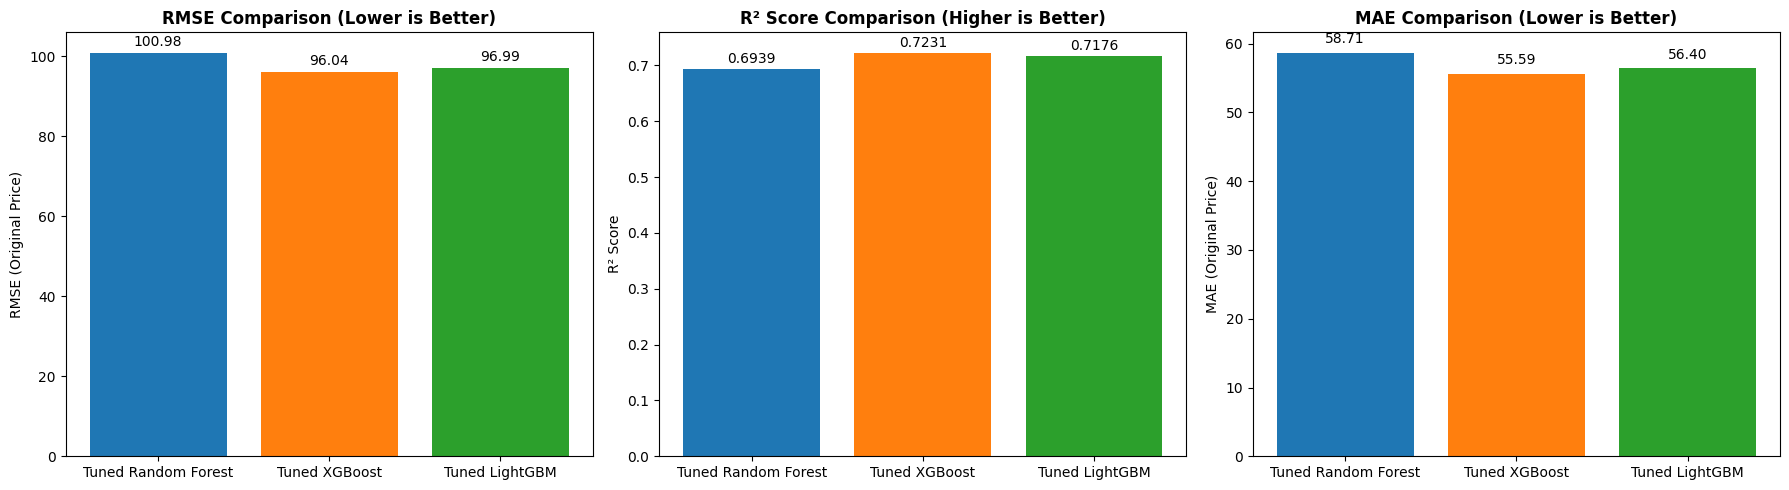


Best Model: Tuned XGBoost


In [17]:
print("=" * 60)
print("MODEL COMPARISON: Baseline vs Tuned (3 Models)")
print("=" * 60)

# Combine all results
all_results = results + tuned_results
all_results_df = pd.DataFrame(all_results)
print(all_results_df.to_string(index=False))

# --- Visualization: Bar Chart Comparison ---
model_names = [r['model'] for r in tuned_results]
rmse_vals = [r['RMSE'] for r in tuned_results]
r2_vals = [r['R2'] for r in tuned_results]
mae_vals = [r['MAE'] for r in tuned_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# RMSE Comparison
bars1 = axes[0].bar(model_names, rmse_vals, color=colors)
axes[0].set_title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (Original Price)')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=10)

# R² Comparison
bars2 = axes[1].bar(model_names, r2_vals, color=colors)
axes[1].set_title('R² Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=10)

# MAE Comparison
bars3 = axes[2].bar(model_names, mae_vals, color=colors)
axes[2].set_title('MAE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MAE (Original Price)')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# --- Select Best Model ---
best_idx = all_results_df['R2'].idxmax()
best_model_name = str(all_results_df.loc[best_idx, 'model'])
print(f"\nBest Model: {best_model_name}")


## 14. Final Comparison & Model Export

In [18]:
print("=" * 60)
print("MODEL EXPORT: Saving Best Model")
print("=" * 60)

# Map the best model name to the actual model object
if 'LightGBM' in best_model_name and 'Tuned' in best_model_name:
    final_model = best_lgbm
elif 'XGBoost' in best_model_name and 'Tuned' in best_model_name:
    final_model = best_xgb
elif 'Random Forest' in best_model_name and 'Tuned' in best_model_name:
    final_model = best_rf
elif 'LightGBM' in best_model_name:
    final_model = lgbm_model
elif 'XGBoost' in best_model_name:
    final_model = xgb_model
elif 'Random Forest' in best_model_name:
    final_model = rf_model
else:
    final_model = best_xgb  # Default

# Export model
joblib.dump(final_model, 'enhanced_price_prediction_model.joblib')
print(f"\nBest model ({best_model_name}) saved as: enhanced_price_prediction_model.joblib")


MODEL EXPORT: Saving Best Model

Best model (Tuned XGBoost) saved as: enhanced_price_prediction_model.joblib


## 15. Model Verification & Prediction Comparison

MODEL VERIFICATION: Actual vs Predicted (50 Samples)
    Actual Price  Predicted Price  Difference  Error %
0          410.0       202.169998      207.83     50.7
1           48.0        45.680000        2.32      4.8
2          159.0       111.339996       47.66     30.0
3          187.0       143.889999       43.11     23.1
4          903.0       603.630005      299.37     33.2
5          545.0       384.790009      160.21     29.4
6          800.0       557.739990      242.26     30.3
7          119.0       165.800003       46.80     39.3
8          104.0       117.949997       13.95     13.4
9          332.0       239.100006       92.90     28.0
10         112.0       138.250000       26.25     23.4
11          51.0        53.369999        2.37      4.6
12         300.0       160.610001      139.39     46.5
13          39.0       143.270004      104.27    267.4
14         145.0        73.330002       71.67     49.4
15          67.0        94.720001       27.72     41.4
16         2

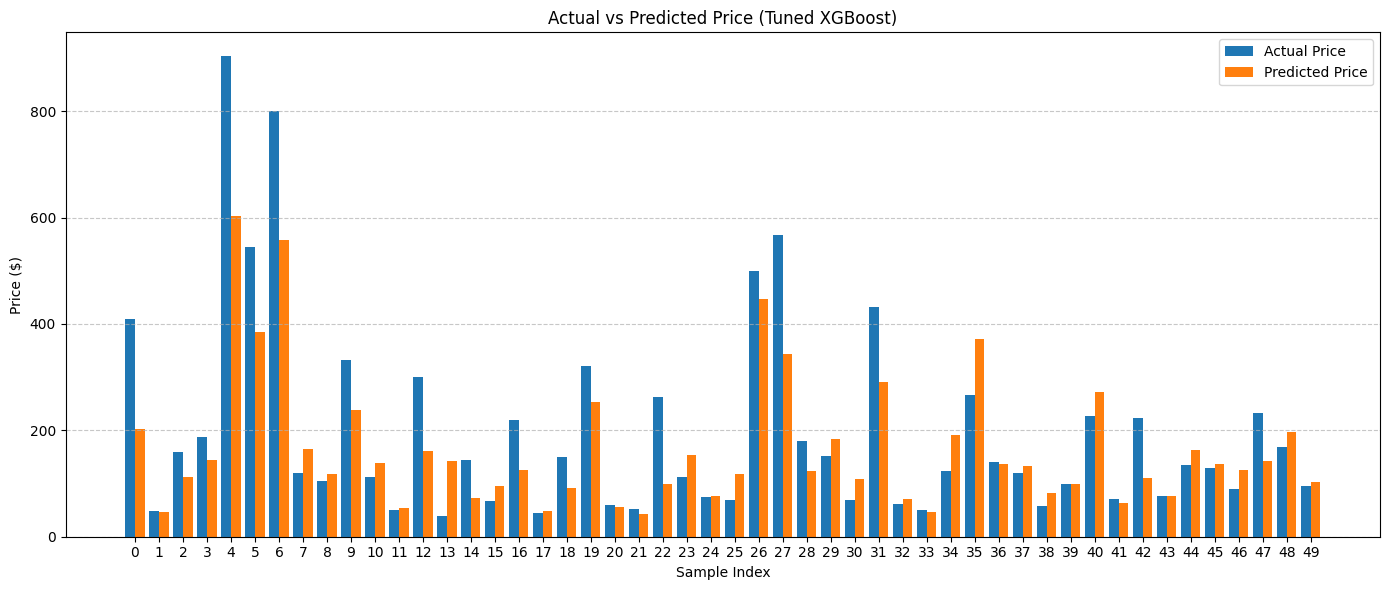


PIPELINE COMPLETE!


In [19]:
print("=" * 60)
print("MODEL VERIFICATION: Actual vs Predicted (50 Samples)")
print("=" * 60)

num_samples = 50
X_test_sample = X_test[:num_samples]
y_true_log = y_test[:num_samples].values
y_pred_log = final_model.predict(X_test_sample)

# Convert from log space back to original price
y_true_orig = np.expm1(y_true_log)
y_pred_orig = np.expm1(y_pred_log)

comparison_df = pd.DataFrame({
    'Actual Price': y_true_orig.round(2),
    'Predicted Price': y_pred_orig.round(2),
    'Difference': abs(y_true_orig - y_pred_orig).round(2),
    'Error %': (abs(y_true_orig - y_pred_orig) / y_true_orig * 100).round(1)
})

print(comparison_df)
print("-" * 50)

# Bar chart visualization
plt.figure(figsize=(14, 6))
x = range(num_samples)
plt.bar([pos - 0.2 for pos in x], y_true_orig, width=0.4,
        label='Actual Price', color='#1f77b4', align='center')
plt.bar([pos + 0.2 for pos in x], y_pred_orig, width=0.4,
        label='Predicted Price', color='#ff7f0e', align='center')
plt.xlabel('Sample Index')
plt.ylabel('Price ($)')
plt.title(f'Actual vs Predicted Price ({best_model_name})')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PIPELINE COMPLETE!")
print("=" * 60)
